In [ ]:
# Google Colab instructions
# Runtime > Change Runtime Type > Runtime Version > 2025.07
# This cell should say you're now on Python Version 3.11.

import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [ ]:
!pip install pycaret openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 8.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 8.5 MB/s eta 0:00:00


In [ ]:
# Before running: Runtime > Restart Session

from pycaret.clustering import *

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

df = pd.read_excel("sipri_data1.xlsx")

In [ ]:
# This fuction helps create all future dendogram visualizations.

def dendro(title):
    dendrogram(linkage(get_config('X_transformed'), method='ward'))
    plt.xlabel('Observations')
    plt.ylabel('Ward Linkage Distance')
    plt.title(title)
    plt.show()

#Clustering Without Dimensionality Reduction

In [ ]:
clustering_pipeline = setup(
    data=df,
    ignore_features=[
        'country',
        'year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    normalize=True,
    normalize_method='zscore',
    session_id=42
)

,Description,Value
0,Session id,42
1,Original data shape,"(180, 19)"
2,Transformed data shape,"(180, 41)"
3,Ignore features,2
4,Numeric features,16
5,Categorical features,1
6,Rows with missing values,70.0%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


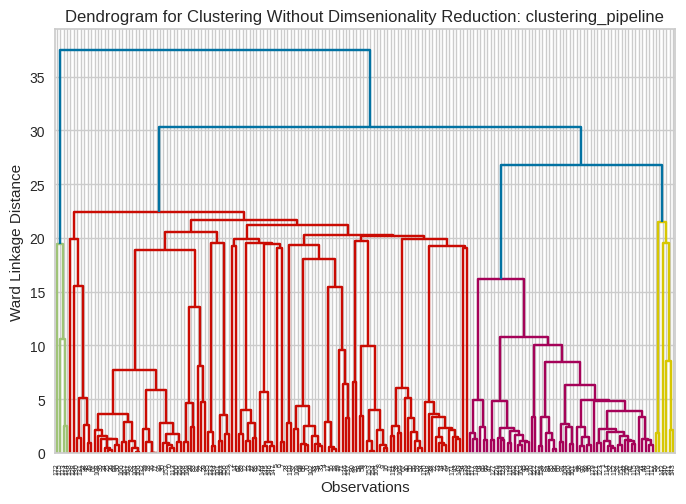

In [ ]:
dendro("Dendrogram for Clustering Without Dimsenionality "
       "Reduction: clustering_pipeline")

This looks atrocious compared to the results we'll get when we use dimensionality reduction.

In [ ]:
print(models())

                                       Name  \
ID                                            
kmeans                   K-Means Clustering   
ap                     Affinity Propagation   
meanshift             Mean Shift Clustering   
sc                      Spectral Clustering   
hclust             Agglomerative Clustering   
dbscan     Density-Based Spatial Clustering   
optics                    OPTICS Clustering   
birch                      Birch Clustering   

                                                   Reference  
ID                                                            
kmeans                        sklearn.cluster._kmeans.KMeans  
ap         sklearn.cluster._affinity_propagation.Affinity...  
meanshift              sklearn.cluster._mean_shift.MeanShift  
sc              sklearn.cluster._spectral.SpectralClustering  
hclust     sklearn.cluster._agglomerative.AgglomerativeCl...  
dbscan                        sklearn.cluster._dbscan.DBSCAN  
optics                   

In [ ]:
kmeans_model = create_model('kmeans', num_clusters=4)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.2167,11.6329,1.1496,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
hclust_model = create_model('hclust', num_clusters=6)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1231,13.0067,2.3107,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

#Linear PCA

In [ ]:
clustering_pipeline2 = setup(
    data=df,
    ignore_features=[
        'country',
        'year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    normalize=True,
    normalize_method='zscore',
    session_id=42,
    pca=True,
    pca_method='linear',
    pca_components=2
)

,Description,Value
0,Session id,42
1,Original data shape,"(180, 19)"
2,Transformed data shape,"(180, 2)"
3,Ignore features,2
4,Numeric features,16
5,Categorical features,1
6,Rows with missing values,70.0%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


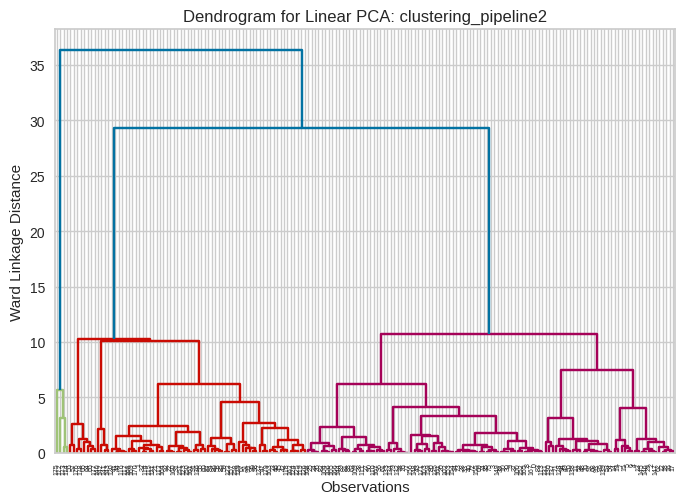

In [ ]:
dendro("Dendrogram for Linear PCA: clustering_pipeline2")

In [ ]:
kmeans_model2 = create_model('kmeans', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5384,297.2208,0.5493,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

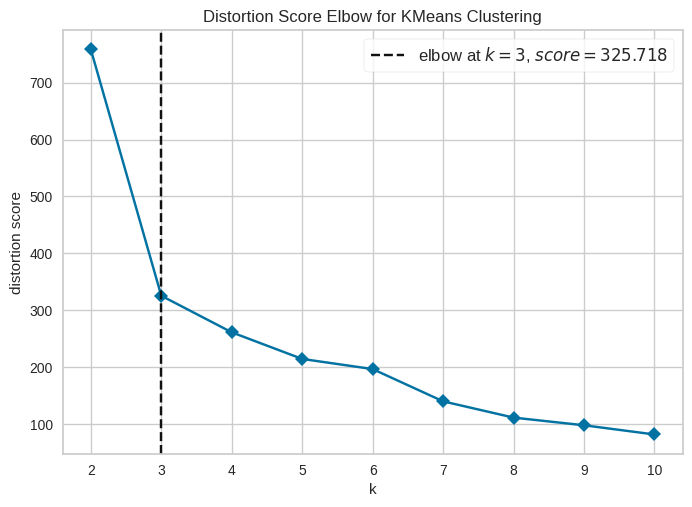

In [ ]:
plot_model(kmeans_model2, plot='elbow')

In [ ]:
plot_model(kmeans_model2, plot='cluster')

In [ ]:
hclust_model2 = create_model('hclust', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.5327,293.1130,0.5519,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

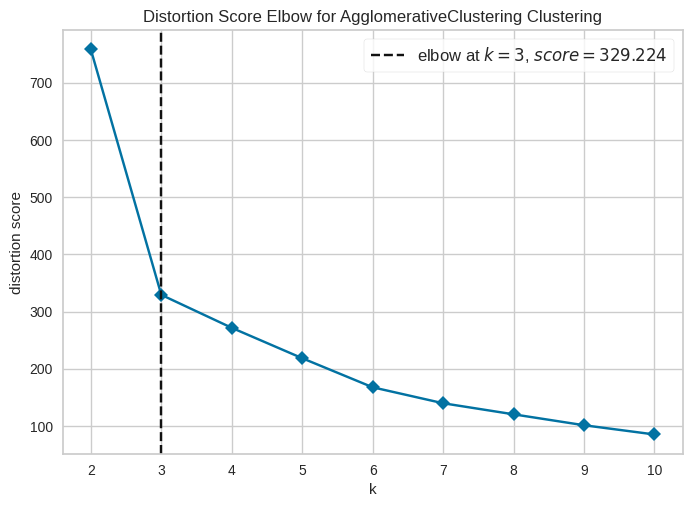

In [ ]:
plot_model(hclust_model2, plot='elbow')

In [ ]:
plot_model(hclust_model2, plot='cluster')

#Non-linear Kernel PCA

In [ ]:
clustering_pipeline3 = setup(
    data=df,
    ignore_features=[
        'country',
        'year'
    ],
    numeric_imputation='mean',
    categorical_imputation='mode',
    normalize=True,
    normalize_method='zscore',
    session_id=42,
    pca=True,
    pca_method='kernel',
    pca_components=2
)

,Description,Value
0,Session id,42
1,Original data shape,"(180, 19)"
2,Transformed data shape,"(180, 2)"
3,Ignore features,2
4,Numeric features,16
5,Categorical features,1
6,Rows with missing values,70.0%
7,Preprocess,True
8,Imputation type,simple
9,Numeric imputation,mean


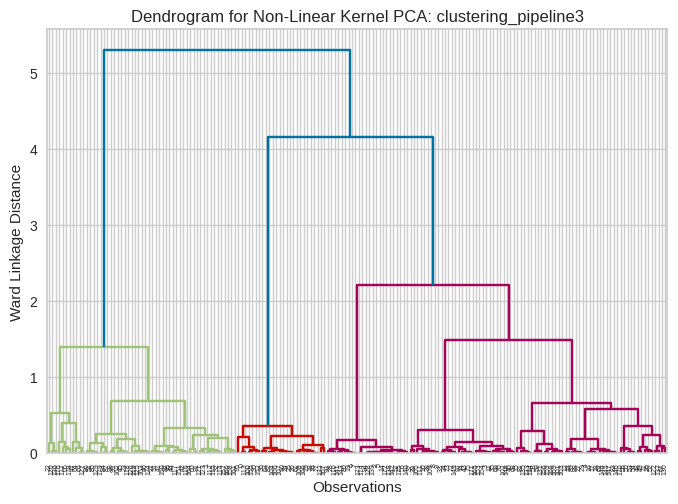

In [ ]:
dendro("Dendrogram for Non-Linear Kernel PCA: clustering_pipeline3")

In [ ]:
kmeans_model3 = create_model('kmeans', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.6504,349.3418,0.4634,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

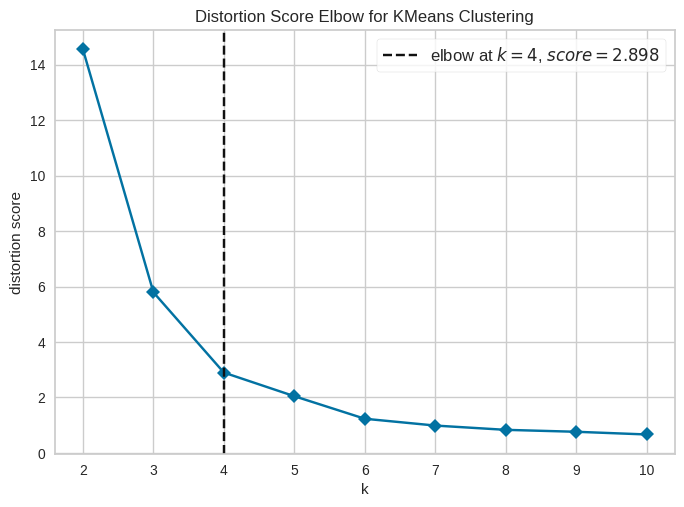

In [ ]:
plot_model(kmeans_model3, plot='elbow')

In [ ]:
plot_model(kmeans_model3, plot='cluster')

In [ ]:
hclust_model3 = create_model('hclust', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.6450,337.0767,0.4802,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

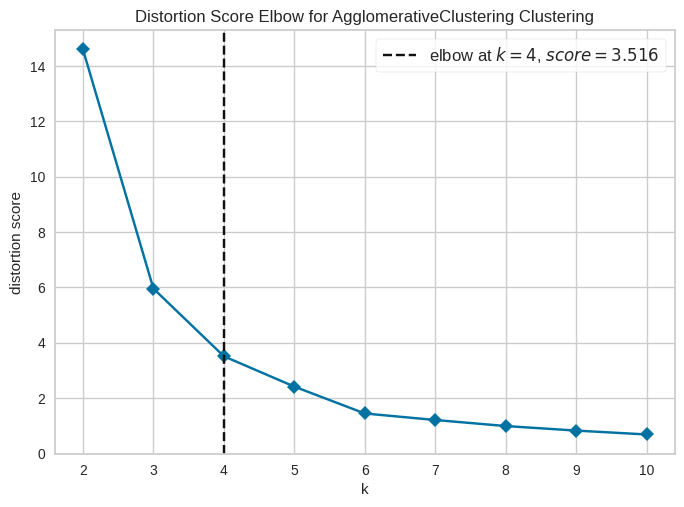

In [ ]:
plot_model(hclust_model3, plot='elbow')

In [ ]:
plot_model(hclust_model3, plot='cluster')